In [310]:
import pandas as pd
import openpyxl
import os
import glob, re
import matplotlib.pyplot as plt

In [311]:
def read_excel(files, sheet):
    dfs = []
    for file in files:
        data = pd.read_excel(file, sheet_name=sheet, index_col=0)
        name = os.path.splitext(os.path.basename(file))[0]
        data['model'] = name
        match = re.search(r'lr[\d.]+_(\d+)_', name)
        if match:
            data['epochs'] = int(match.group(1))
        match_model = re.search(r'model_.*?_e_(.*?)_lr', name)
        if match_model:
            data['id'] = match_model.group(1)
        dfs.append(data)
    df = pd.concat(dfs,ignore_index=True)
    return df

In [312]:
def arrange_data(df, error):
    df = df.pivot(index='model', columns='error', values=error)
    return df

In [313]:
def min_vals(df, error):
    df1 = df.apply(lambda x: pd.Series({'model':x.idxmin(), error:x.min()})).T
    return df1

In [314]:
def min(df, error):
    df = df.pivot(index='model', columns='error', values=error)
    df1 = df.apply(lambda x: pd.Series({'model':x.idxmin(), error:x.min()})).T
    return df1

In [315]:
path = "model_Fe_Si_B_260311/**/test_res/*_test.xlsx"

In [316]:
files = glob.glob(path, recursive=True)

In [317]:
df = read_excel(files, 'errors')
df = df[['id', 'epochs']+[c for c in df.columns if c not in ['id', 'epochs']]]
#df

In [347]:
def plot_global_error(dfs,x,y_cols, df_labels, titles, tag):
    fig, axes = plt.subplots(1,len(dfs), sharey=True)

    if len(dfs) == 1:
        axes = [axes]

    handles =[]
    labels = []
    markers = {'mae': 'o', 'rmse': '^'}
    #esto es lo que acabo de agregar
    #colors = dict(zip(df_labels, ['blue', 'red', 'green']))
    model_colors = {'scmace': 'blue', 'scmace_nofe8b4':'red', 'matpes':'green', 'matpes_nofe8b4': 'orange'}
    #

    for i, group in enumerate(dfs):
        ax = axes[i]
        for df, df_label in zip(group, df_labels):
            for y in y_cols:
                label = f'{y}_{df_label}'
                color = model_colors.get(df_label)
                line = ax.scatter(df[x], df[y], marker=markers.get(y,'o'), color=color, label=f'{y}_{df_label}')
                if label not in labels:
                    handles.append(line)
                    labels.append(label)
        ax.set_xlabel(f'{x}')
        ax.set_title(titles[i])
    
    if tag == 'energy':
        units = 'meV/atom'
    elif tag == 'force': 
        units = r'meV/$\AA$'
    
    fig.legend(handles, labels, loc='outside lower center', bbox_to_anchor=(0.5,-0.1), fontsize=7)
    fig.suptitle(f'MAE and RMSE in {units} for {df_labels} model')
    plt.tight_layout()

In [348]:
def plot_config_error(dfs, y, titles, error, model_name):
    fig, axes = plt.subplots(1, len(dfs), figsize=(10,6), sharey=True)
    if len(dfs) == 1:
        axes = [axes]

    for i, df in enumerate(dfs):
        ax = axes[i]
        for config, group in df.groupby('config'):
            n_config = group['n_configs'].iloc[0]
            label = f'{config} (n={n_config})'
            ax.scatter(group['epochs'], group[y],marker='o',label=label)
        ax.set_xlabel('Epochs')
        ax.set_title(titles[i])

        handles, labels = ax.get_legend_handles_labels()
        unique = dict(zip(labels,handles))

        ax.legend(unique.values(), unique.keys(), fontsize=7, bbox_to_anchor=(0.5,-0.1))
    fig.suptitle(f'{error}_(meV/atom) for {model_name} model')
    plt.tight_layout()

In [349]:
#df

In [375]:
#voy a generar un dataframe para cada modelo
scmace = df.query('id == "scmace"')
#matpes = df.query('id == "matpes"')
matpes = df.query('id == "matpes" & epochs != 500') #esto es ahorita que no quiero ver el de 500 epochs
scmace_nofe8b4 = df.query('id == "scmace_nofe8b4"')
matpes_nofe8b4 = df.query('id == "matpes_nofe8b4"')

In [377]:
scmace_test_e = scmace.query('error == "test_energy"')
scmace_train_e = scmace.query('error == "train_energy"')
matpes_test_e = matpes.query('error == "test_energy"')
matpes_train_e = matpes.query('error == "train_energy"')
scmace_test_f = scmace.query('error == "test_force"')
scmace_train_f = scmace.query('error == "train_force"')
matpes_test_f = matpes.query('error == "test_force"')
matpes_train_f = matpes.query('error == "train_force"')
scmace_nofe8b4_test_e = scmace_nofe8b4.query('error == "test_energy"')
scmace_nofe8b4_train_e = scmace_nofe8b4.query('error == "train_energy"')
scmace_nofe8b4_test_f = scmace_nofe8b4.query('error == "test_force"')
scmace_nofe8b4_train_f = scmace_nofe8b4.query('error == "train_force"')
matpes_nofe8b4_test_e = matpes_nofe8b4.query('error == "test_energy"')
matpes_nofe8b4_train_e = matpes_nofe8b4.query('error == "train_energy"')
matpes_nofe8b4_test_f = matpes_nofe8b4.query('error == "test_force"')
matpes_nofe8b4_train_f = matpes_nofe8b4.query('error == "train_force"')

In [378]:
#plot_global_error([[scmace_test_e, matpes_test_e], [scmace_train_e, matpes_train_e]], 'epochs', ['mae', 'rmse'], ['scmace', 'matpes'], ['Test data', 'Train data'])

In [379]:
df.query('epochs == 100 & error == ["test_energy", "train_energy"]').sort_values('mae', ascending=True)

,id,epochs,error,rmse,mae,r2,model
21,matpes,100,train_energy,100.094452,23.863738,0.951146,model_rnd_e_matpes_lr0.0001_100_10_test
20,matpes,100,test_energy,41.652997,24.019415,0.990589,model_rnd_e_matpes_lr0.0001_100_10_test
1,scmace_nofe8b4,100,train_energy,152.843047,87.474704,0.826808,model_rnd_e_scmace_nofe8b4_lr0.0001_100_10_test
5,scmace,100,train_energy,212.670122,104.387671,0.779457,model_rnd_e_scmace_lr0.0001_100_10_test
0,scmace_nofe8b4,100,test_energy,182.857256,111.988795,0.768530,model_rnd_e_scmace_nofe8b4_lr0.0001_100_10_test
4,scmace,100,test_energy,210.180375,124.774518,0.760373,model_rnd_e_scmace_lr0.0001_100_10_test


In [380]:
df.query('epochs == 100 & error == ["test_force", "train_force"]').sort_values('mae', ascending=True)

,id,epochs,error,rmse,mae,r2,model
23,matpes,100,train_force,0.136716,0.105124,0.997585,model_rnd_e_matpes_lr0.0001_100_10_test
22,matpes,100,test_force,0.159079,0.119892,0.996762,model_rnd_e_matpes_lr0.0001_100_10_test
7,scmace,100,train_force,350.138568,264.249749,0.984159,model_rnd_e_scmace_lr0.0001_100_10_test
6,scmace,100,test_force,473.278983,266.765534,0.971340,model_rnd_e_scmace_lr0.0001_100_10_test
3,scmace_nofe8b4,100,train_force,359.272682,271.715308,0.983527,model_rnd_e_scmace_nofe8b4_lr0.0001_100_10_test
2,scmace_nofe8b4,100,test_force,481.067536,273.399745,0.970672,model_rnd_e_scmace_nofe8b4_lr0.0001_100_10_test


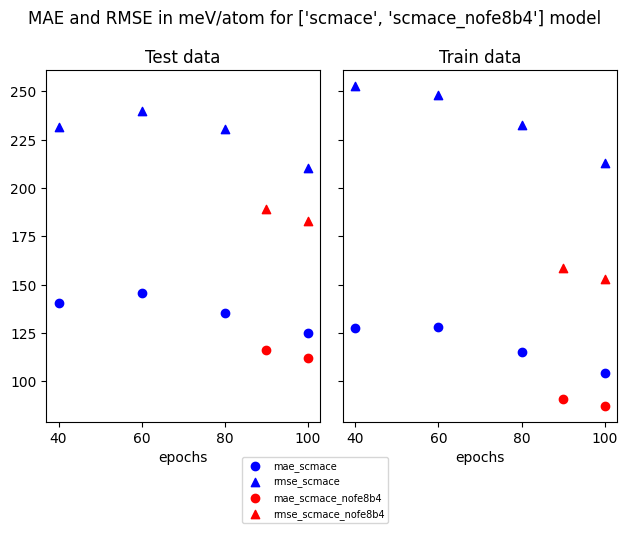

In [381]:
plot_global_error([[scmace_test_e, scmace_nofe8b4_test_e], [scmace_train_e, scmace_nofe8b4_train_e]], 'epochs', ['mae', 'rmse'], ['scmace', 'scmace_nofe8b4'], ['Test data', 'Train data'], 'energy')

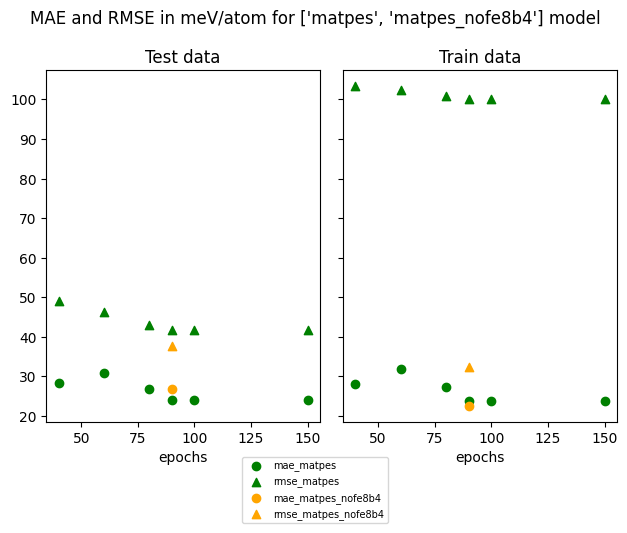

In [382]:
plot_global_error([[matpes_test_e, matpes_nofe8b4_test_e], [matpes_train_e, matpes_nofe8b4_train_e]], 'epochs', ['mae', 'rmse'], ['matpes', 'matpes_nofe8b4'], ['Test data', 'Train data'], 'energy')

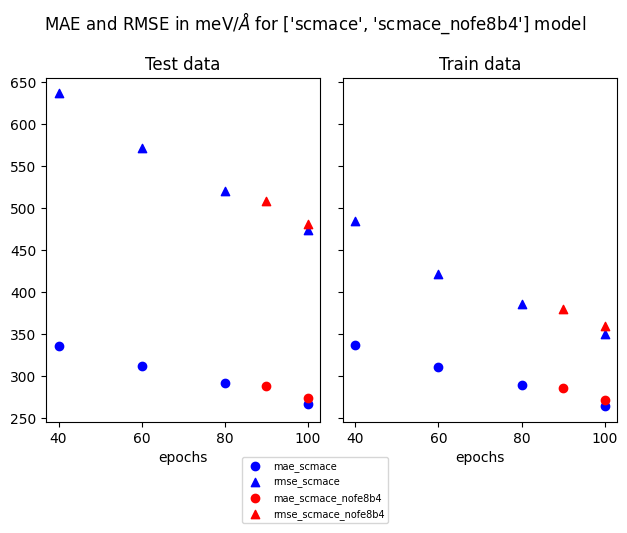

In [383]:
plot_global_error([[scmace_test_f, scmace_nofe8b4_test_f], [scmace_train_f, scmace_nofe8b4_train_f]], 'epochs', ['mae', 'rmse'], ['scmace', 'scmace_nofe8b4'], ['Test data', 'Train data'], 'force')

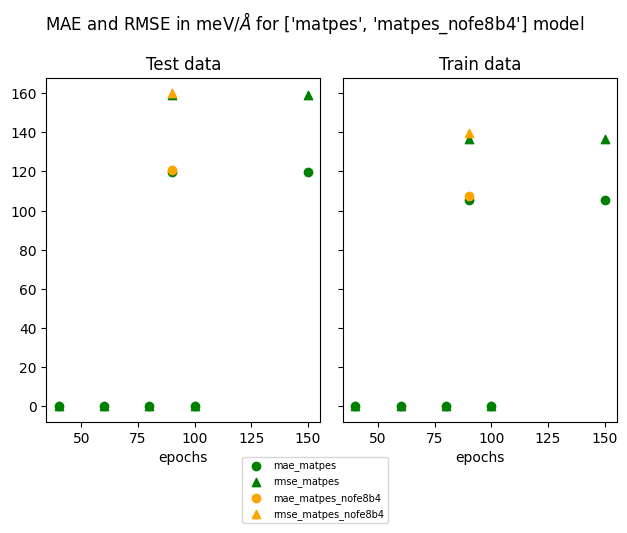

In [399]:
plot_global_error([[matpes_test_f, matpes_nofe8b4_test_f], [matpes_train_f, matpes_nofe8b4_train_f]], 'epochs', ['mae', 'rmse'], ['matpes', 'matpes_nofe8b4'], ['Test data', 'Train data'], 'force')

In [400]:
min(scmace, 'mae')

,model,mae
error,,
test_energy,model_rnd_e_scmace_lr0.0001_100_10_test,124.774518
test_force,model_rnd_e_scmace_lr0.0001_100_10_test,266.765534
train_energy,model_rnd_e_scmace_lr0.0001_100_10_test,104.387671
train_force,model_rnd_e_scmace_lr0.0001_100_10_test,264.249749


In [401]:
min(matpes, 'mae')

,model,mae
error,,
test_energy,model_rnd_e_matpes_lr0.0001_100_10_test,24.019415
test_force,model_rnd_e_matpes_lr0.0001_100_10_test,0.119892
train_energy,model_rnd_e_matpes_lr0.0001_100_10_test,23.863738
train_force,model_rnd_e_matpes_lr0.0001_100_10_test,0.105124


In [402]:
min(pd.concat([scmace_nofe8b4, scmace], join='inner'), 'mae')

,model,mae
error,,
test_energy,model_rnd_e_scmace_nofe8b4_lr0.0001_100_10_test,111.988795
test_force,model_rnd_e_scmace_lr0.0001_100_10_test,266.765534
train_energy,model_rnd_e_scmace_nofe8b4_lr0.0001_100_10_test,87.474704
train_force,model_rnd_e_scmace_lr0.0001_100_10_test,264.249749


In [414]:
min(pd.concat([matpes_nofe8b4, matpes], join='inner'), 'mae')

,model,mae
error,,
test_energy,model_rnd_e_matpes_lr0.0001_100_10_test,24.019415
test_force,model_rnd_e_matpes_lr0.0001_100_10_test,0.119892
train_energy,model_rnd_e_matpes_nofe8b4_lr0.0001_90_10_test,22.588262
train_force,model_rnd_e_matpes_lr0.0001_100_10_test,0.105124


In [429]:
min(df, 'mae')

,model,mae
error,,
test_energy,model_rnd_e_matpes_lr0.0001_100_10_test,24.019415
test_force,model_rnd_e_matpes_lr0.0001_100_10_test,0.119892
train_energy,model_rnd_e_matpes_nofe8b4_lr0.0001_90_10_test,22.588262
train_force,model_rnd_e_matpes_lr0.0001_100_10_test,0.105124


Reading the config errors

In [417]:
df_config =read_excel(files, 'config_errors')
df_config = df_config[['id', 'epochs', 'config', 'n_configs', 'mae', 'rmse', 'error', 'model']]
#df_config

In [418]:
scmace_config_test_e = df_config.query('id == "scmace" & error == "test_energy"')#.sort_values('mae', ascending=True)
scmace_config_train_e = df_config.query('id == "scmace" & error == "train_energy"')
#matpes_config_test_e = df_config.query('id == "matpes" & error == "test_energy"')
#matpes_config_train_e = df_config.query('id == "matpes" & error == "train_energy"')
#esto es para ahorita que no quiero ver el de 500 epochs
matpes_config_test_e = df_config.query('id == "matpes" & error == "test_energy" & epochs != 500')
matpes_config_train_e = df_config.query('id == "matpes" & error == "train_energy" & epochs != 500')
scmace_nofe8b4_config_test_e = df_config.query('id == "scmace_nofe8b4" & error == "test_energy"')
scmace_nofe8b4_config_train_e = df_config.query('id == "scmace_nofe8b4" & error == "train_energy"')
matpes_nofe8b4_config_test_e = df_config.query('id == "matpes_nofe8b4" & error == "test_energy"')
matpes_nofe8b4_config_train_e = df_config.query('id == "matpes_nofe8b4" & error == "train_energy"')

In [419]:
#pd.concat([scmace_nofe8b4_config_test_e, scmace_config_test_e], join='inner').query('epochs == 100').sort_values('config')

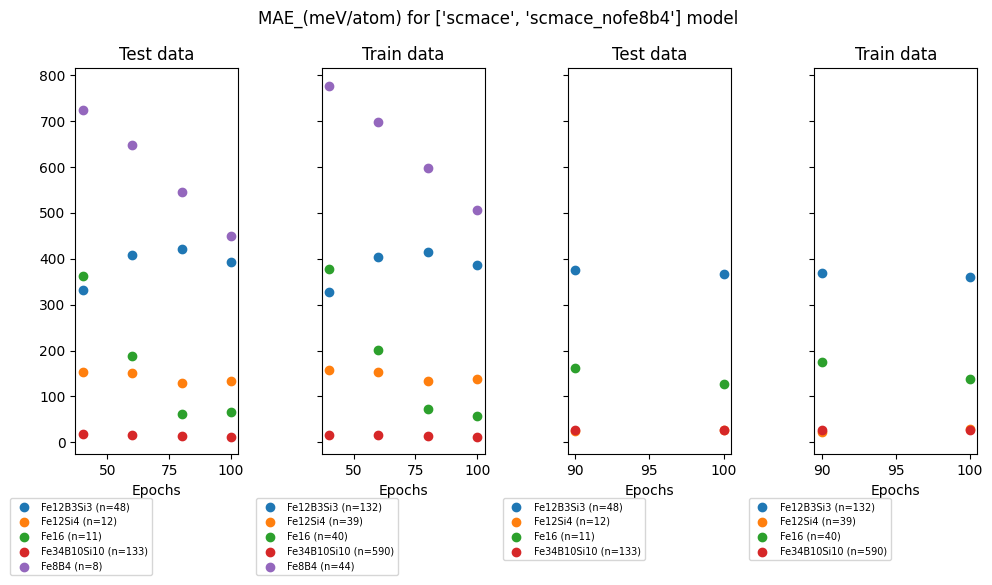

In [420]:
plot_config_error([scmace_config_test_e, scmace_config_train_e, scmace_nofe8b4_config_test_e, scmace_nofe8b4_config_train_e], 'mae', ['Test data', 'Train data', 'Test data', 'Train data'], 'MAE', ['scmace', 'scmace_nofe8b4'])

In [421]:
scmace_config_test_e1 = scmace_config_test_e.query('config != "Fe8B4"')
scmace_config_train_e1 = scmace_config_train_e.query('config != "Fe8B4"')

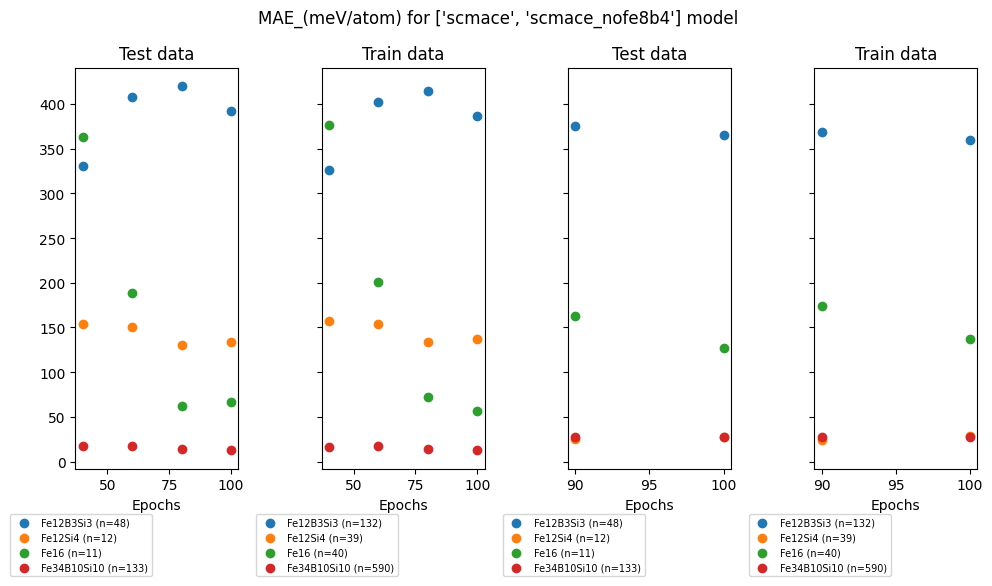

In [422]:
plot_config_error([scmace_config_test_e1, scmace_config_train_e1, scmace_nofe8b4_config_test_e, scmace_nofe8b4_config_train_e], 'mae', ['Test data', 'Train data', 'Test data', 'Train data'], 'MAE', ['scmace', 'scmace_nofe8b4'])

In [423]:
#plot_config_error([scmace_nofe8b4_config_test_e, scmace_nofe8b4_config_train_e], 'mae', ['Test data', 'Train data'], 'MAE')

In [ ]:
matpes

In [427]:
matpes_nofe8b4_config_test_e

,id,epochs,config,n_configs,mae,rmse,error,model
28,matpes_nofe8b4,90,Fe12B3Si3,48,73.055520,73.444903,test_energy,model_rnd_e_matpes_nofe8b4_lr0.0001_90_10_test
29,matpes_nofe8b4,90,Fe12Si4,12,3.151902,3.674366,test_energy,model_rnd_e_matpes_nofe8b4_lr0.0001_90_10_test
30,matpes_nofe8b4,90,Fe16,11,19.019727,19.172899,test_energy,model_rnd_e_matpes_nofe8b4_lr0.0001_90_10_test
31,matpes_nofe8b4,90,Fe34B10Si10,133,12.988133,13.685046,test_energy,model_rnd_e_matpes_nofe8b4_lr0.0001_90_10_test


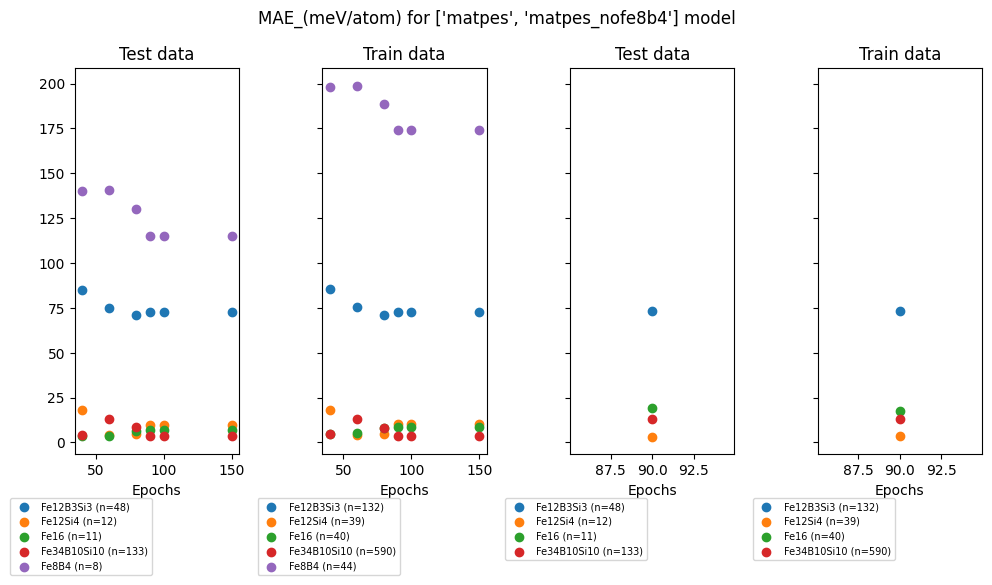

In [428]:
plot_config_error([matpes_config_test_e, matpes_config_train_e, matpes_nofe8b4_config_test_e, matpes_nofe8b4_config_train_e], 'mae', ['Test data', 'Train data', 'Test data', 'Train data'], 'MAE', ['matpes', 'matpes_nofe8b4'])

In [432]:
#df_config.query('id == "scmace" & error == "train_energy"').sort_values('mae', ascending=True)

In [431]:
#df_config.query('id == "matpes" & error == "test_energy"').sort_values('mae', ascending=True)

In [430]:
#df_config.query('id == "matpes" & error == "train_energy"').sort_values('mae', ascending=True)